<a href="https://colab.research.google.com/github/andandandand/practical-computer-vision/blob/main/notebooks/Nemotron_Omni_and_Parse_using_the_NIM_endpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nvidia Inference Microservice API calls for Nemotron Models


Follow the instructions [here](https://github.com/andandandand/practical-computer-vision/blob/main/docs/Setup_NVIDIA_API_KEY.md) to obtain an API key and include it into Google Colab.


In [1]:
from google.colab import userdata
NVIDIA_API_KEY = userdata.get('NVIDIA_API_KEY')

## Nemotron 3 Nano Omni

Nemotron 3 Nano Omni is able to understand visual and audio input. It is a reasoning model that also has tool calling abilities.

https://build.nvidia.com/nvidia/nemotron-3-nano-omni-30b-a3b-reasoning

https://arxiv.org/abs/2604.24954

https://huggingface.co/nvidia/Nemotron-3-Nano-Omni-30B-A3B-Reasoning-BF16

In [2]:
import os
from openai import OpenAI

client = OpenAI(
    base_url="https://integrate.api.nvidia.com/v1",
    api_key=NVIDIA_API_KEY
)

prompt = "Write a short explanation of Nemotron for a Python developer."

completion = client.chat.completions.create(
    model="nvidia/nemotron-3-nano-omni-30b-a3b-reasoning",
    messages=[
        {"role": "user", "content": prompt}
    ],
    temperature=0.6,
    top_p=0.95,
    max_tokens=65536,
    extra_body={
        "chat_template_kwargs": {"enable_thinking": True},
        "reasoning_budget": 16384
    },
    stream=False
)

reasoning = getattr(completion.choices[0].message, "reasoning_content", None)
if reasoning:
    print(reasoning)

print(completion.choices[0].message.content)

We need to write a short explanation of "Nemotron" for a Python developer. Likely Nemotron is a language model from NVIDIA (maybe a code generation model). Provide concise description, its capabilities, how to use, maybe via API or local, integration with Python, etc. Keep short. Ensure no disallowed content. Provide explanation.

**Nemotron – a quick rundown for Python developers**

Nemotron is NVIDIA’s family of large‑language‑model (LLM) tools built for high‑performance, code‑centric workflows. Think of it as a powerful, GPU‑accelerated “smart assistant” that can understand and generate Python (and many other languages) with a focus on speed, accuracy, and seamless integration into existing development pipelines.

### Why it matters to you
| Feature | What it means for a Python dev |
|---------|--------------------------------|
| **GPU‑native inference** | Runs orders of magnitude faster than CPU‑only models, so you get near‑real‑time completions even for large prompts. |
| **Fine‑t

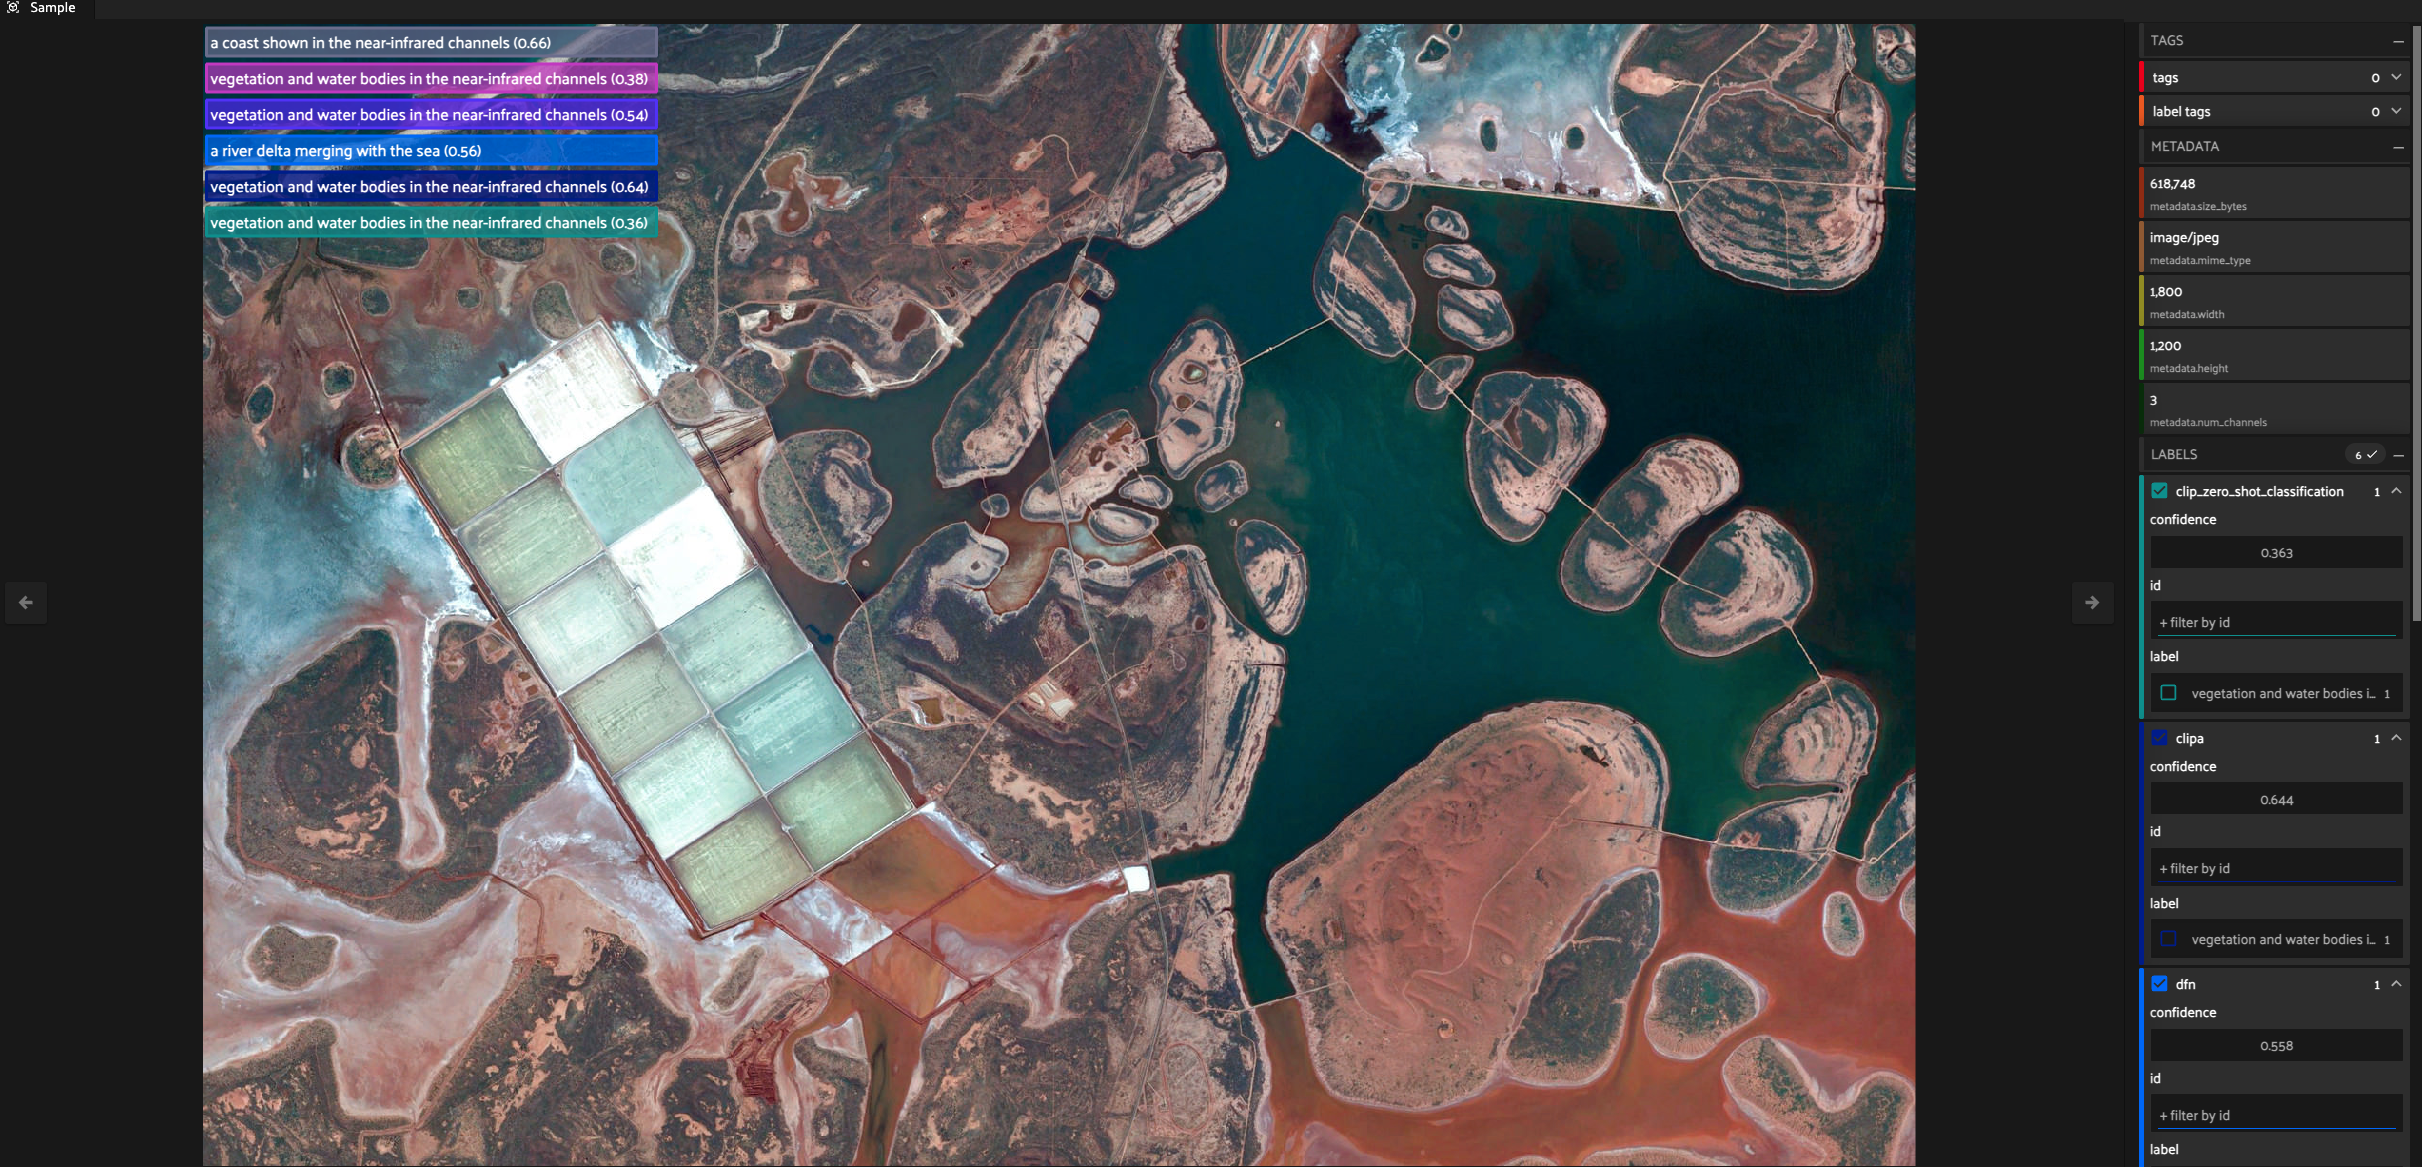

In [3]:
import skimage.io as io
from PIL import Image
image_url="https://github.com/andandandand/practical-computer-vision/blob/main/images/clip_ensemble_labels.png?raw=1"
img = Image.fromarray(io.imread(image_url))
img

In [4]:
image_url = "https://github.com/andandandand/practical-computer-vision/blob/main/images/clip_ensemble_labels.png?raw=1"

completion = client.chat.completions.create(
    model="nvidia/nemotron-3-nano-omni-30b-a3b-reasoning",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "Describe this image in detail. Explain what it shows and mention any visible labels or structure."
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": image_url
                    }
                }
            ]
        }
    ],
    temperature=0.2,
    max_tokens=2000,
    stream=False
)

print(completion.choices[0].message.content)

This image displays a satellite or aerial imagery analysis interface, likely from a geospatial AI tool. Here's a detailed breakdown:

### **Main Visual Content (Center)**
- A high-resolution satellite image of a coastal region.
- **Key Features**:
  - A large, rectangular area in the lower-left quadrant consists of a grid of segmented plots (likely human-made, such as salt evaporation ponds or agricultural fields). These plots show varying colors (green, white, brownish), indicating different land cover types or stages of processing.
  - Surrounding the grid is a mix of natural terrain: arid, brownish land with circular patterns (possibly salt flats or dried lake beds), and a large body of dark teal water (a bay or sea inlet).
  - The water has several small, irregular islands or peninsulas, creating a complex shoreline.

### **Left Panel: Classification Labels**
- A vertical list of predicted labels with confidence scores (e.g., "a coast shown in the near-infrared channels (0.66)", "v

In [5]:
from IPython.display import Markdown, display
display(Markdown(completion.choices[0].message.content))

This image displays a satellite or aerial imagery analysis interface, likely from a geospatial AI tool. Here's a detailed breakdown:

### **Main Visual Content (Center)**
- A high-resolution satellite image of a coastal region.
- **Key Features**:
  - A large, rectangular area in the lower-left quadrant consists of a grid of segmented plots (likely human-made, such as salt evaporation ponds or agricultural fields). These plots show varying colors (green, white, brownish), indicating different land cover types or stages of processing.
  - Surrounding the grid is a mix of natural terrain: arid, brownish land with circular patterns (possibly salt flats or dried lake beds), and a large body of dark teal water (a bay or sea inlet).
  - The water has several small, irregular islands or peninsulas, creating a complex shoreline.

### **Left Panel: Classification Labels**
- A vertical list of predicted labels with confidence scores (e.g., "a coast shown in the near-infrared channels (0.66)", "vegetation and water bodies in the near-infrared channels (0.64)").
- These labels suggest the image was analyzed using a machine learning model trained on near-infrared spectral data, identifying features like coastlines, vegetation, water bodies, and river deltas.

### **Right Panel: Metadata and Labels**
- **TAGS Section**: Empty (0 items for "tags" and "label tags").
- **METADATA Section**:
  - File size: 618,748 bytes.
  - Format: `image/jpeg` (MIME type).
  - Dimensions: 1,800 (width) × 1,200 (height).
  - Channels: 3 (indicating RGB color channels).
- **LABELS Section**:
  - Contains structured label data with confidence scores:
    - **`clip_zero_shot_classification`**: Confidence 0.363; label "vegetation and water bodies l..." (truncated).
    - **`clipa`**: Confidence 0.644; label "vegetation and water bodies l..." (truncated).
    - **`dfn`**: Confidence 0.558; label field empty.
  - Each label entry includes an `id` field and a `label` field, with checkboxes for selection.

### **Overall Structure**
- The interface is split into three parts: the central image, a left-side list of high-level predictions, and a right-side panel with technical metadata and detailed label information.
- The presence of "near-infrared channels" in labels and the 3-channel metadata suggests this is multispectral imagery analysis, where near-infrared data enhances vegetation/water distinctions.

## Suggested Experiments

* Try running inference on an audio clip or a video segment.

* Try setting modifying the reasoning budget and putting the model into a [LangGraph](https://academy.langchain.com/courses/intro-to-langgraph) harness that browses the web.

## Nemotron Parse

Nemotron Parse is Optical Character Recognition model. It is able to extract text from images into structured format. It also provides a canonical reading order for the parsed components.

https://build.nvidia.com/nvidia/nemotron-parse

https://arxiv.org/pdf/2511.20478

https://huggingface.co/nvidia/NVIDIA-Nemotron-Parse-v1.2

In [6]:
import os
import base64
import json
import mimetypes
import requests

nvai_url = "https://integrate.api.nvidia.com/v1/chat/completions"

# Fixed the f-string to use the actual NVIDIA_API_KEY variable
headers = {
    "Authorization": f"Bearer {NVIDIA_API_KEY}",
    "Accept": "application/json",
    "Content-Type": "application/json",
}

tools = [
    "markdown_bbox",
    "markdown_no_bbox",
    "detection_only",
]

def _read_image_as_base64(path):
    with open(path, "rb") as f:
        data = f.read()
    b64 = base64.b64encode(data).decode("ascii")
    mime, _ = mimetypes.guess_type(path)
    if mime is None:
        mime = "image/jpeg"
    return b64, mime

def _generate_content(task_id, b64_str, mime):
    if task_id < 0 or task_id >= len(tools):
        raise ValueError(f"task_id should be within [0, {len(tools)-1}]")
    tool_name = tools[task_id]
    media_tag = f'<img src="data:{mime};base64,{b64_str}" />'
    content = f"{media_tag}"
    tool_spec = [{"type": "function", "function": {"name": tool_name}}]
    return content, tool_spec, tool_name



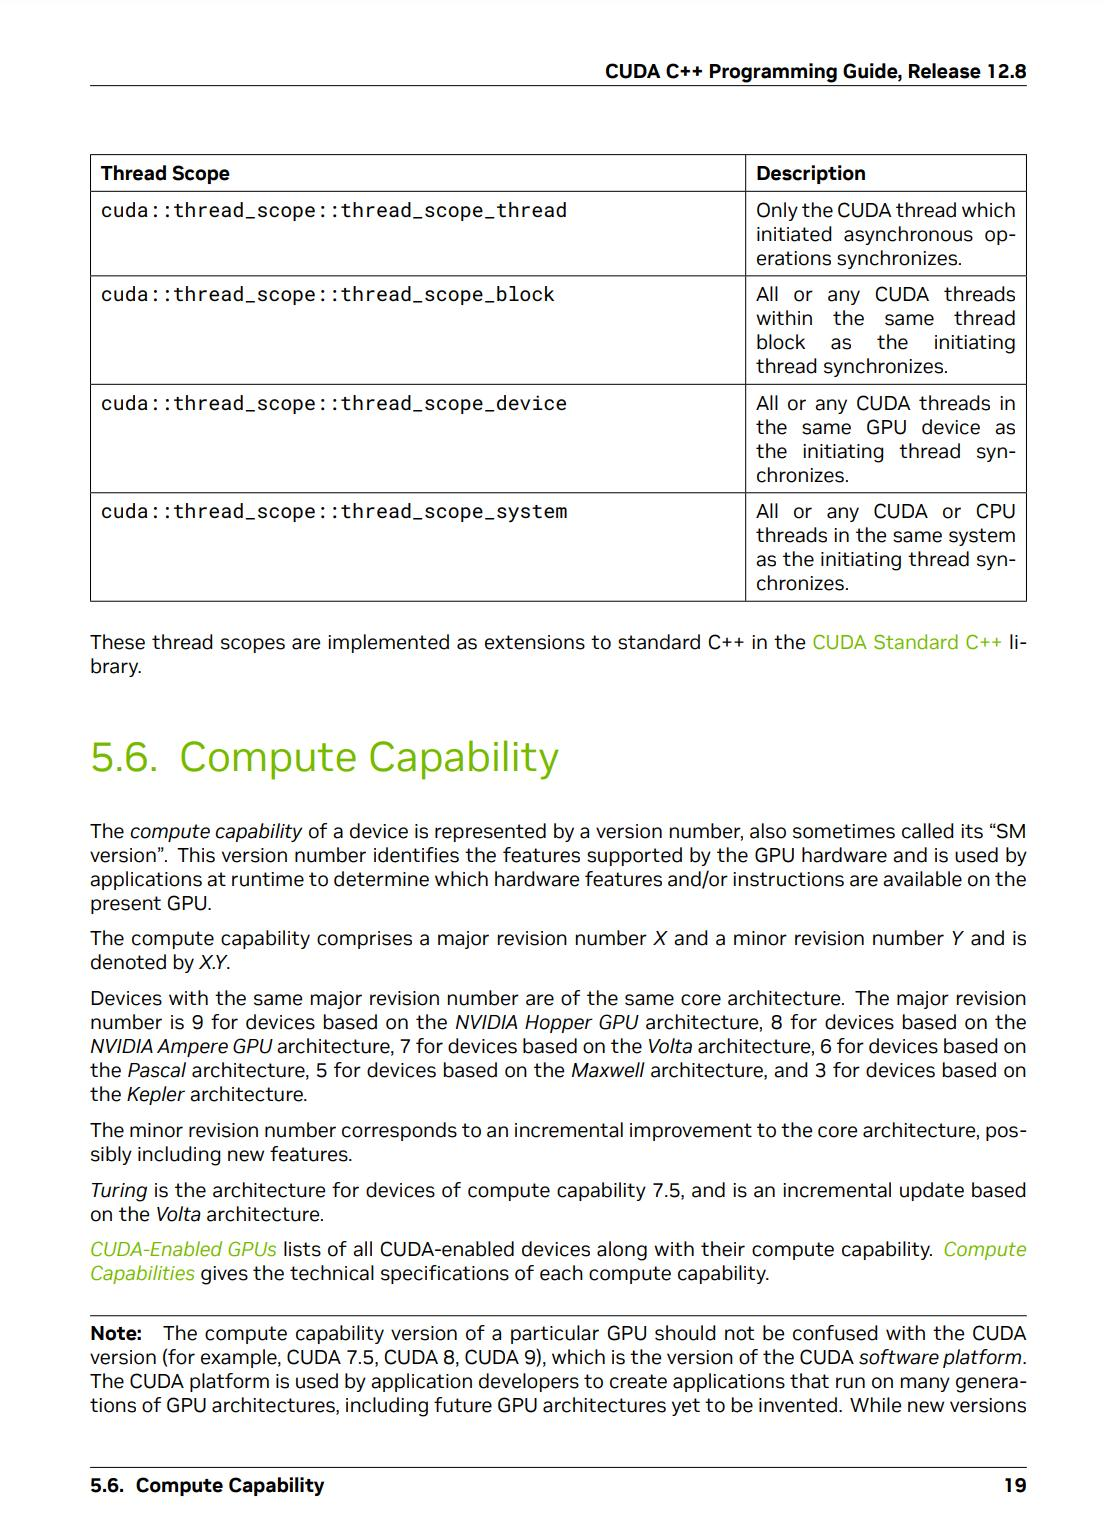

In [7]:
# Download a sample image for parsing
image_url_2 = "https://github.com/andandandand/practical-computer-vision/blob/main/images/cuda-compute-capability.jpeg?raw=1"
imag_test_2 = Image.fromarray(io.imread(image_url_2))
imag_test_2


In [8]:
image_path = "./cuda_image.jpg"

imag_test_2.save(image_path)
# Set task_id directly instead of using sys.argv
task_id = 0

b64_str, mime = _read_image_as_base64(image_path)
content, tool_spec, tool_name = _generate_content(task_id, b64_str, mime)

inputs = {
    "model": "nvidia/nemotron-parse",
    "messages": [
        {
            "role": "user",
            "content": content
        }
    ],
    "tools": tool_spec,
    "tool_choice": {"type": "function", "function": {"name": tool_name}},
    "max_tokens": 8192,
}

response = requests.post(nvai_url, headers=headers, json=inputs, timeout=120)
try:
    response.raise_for_status()
except requests.HTTPError as e:
    print("Status:", response.status_code)
    print("Body:", response.text)
    raise

parse_result = response.json()
print(json.dumps(parse_result, ensure_ascii=False, indent=2))

{
  "id": "chatcmpl-6496b3082c504680a1bf48d6d7c5b03b",
  "object": "chat.completion",
  "created": 1782217977,
  "model": "nvidia/nemotron-parse",
  "choices": [
    {
      "index": 0,
      "message": {
        "role": "assistant",
        "content": null,
        "refusal": null,
        "annotations": null,
        "audio": null,
        "function_call": null,
        "tool_calls": [
          {
            "id": "chatcmpl-tool-16dc64de966245feadb655516ace230b",
            "type": "function",
            "function": {
              "name": "markdown_bbox",
              "arguments": "[[{\"bbox\": {\"xmin\": 0.5306014492753623, \"ymin\": 0.022503057905009758, \"xmax\": 0.9387202898550726, \"ymax\": 0.05688067664281066}, \"text\": \"**CUDA C++ Programming Guide, Release 12.8**\", \"type\": \"Page-header\"}, {\"bbox\": {\"xmin\": 0.07426666666666663, \"ymin\": 0.3962597267404034, \"xmax\": 0.9358840579710146, \"ymax\": 0.44409525048796356}, \"text\": \"These thread scopes are impleme

Found 12 bounding boxes


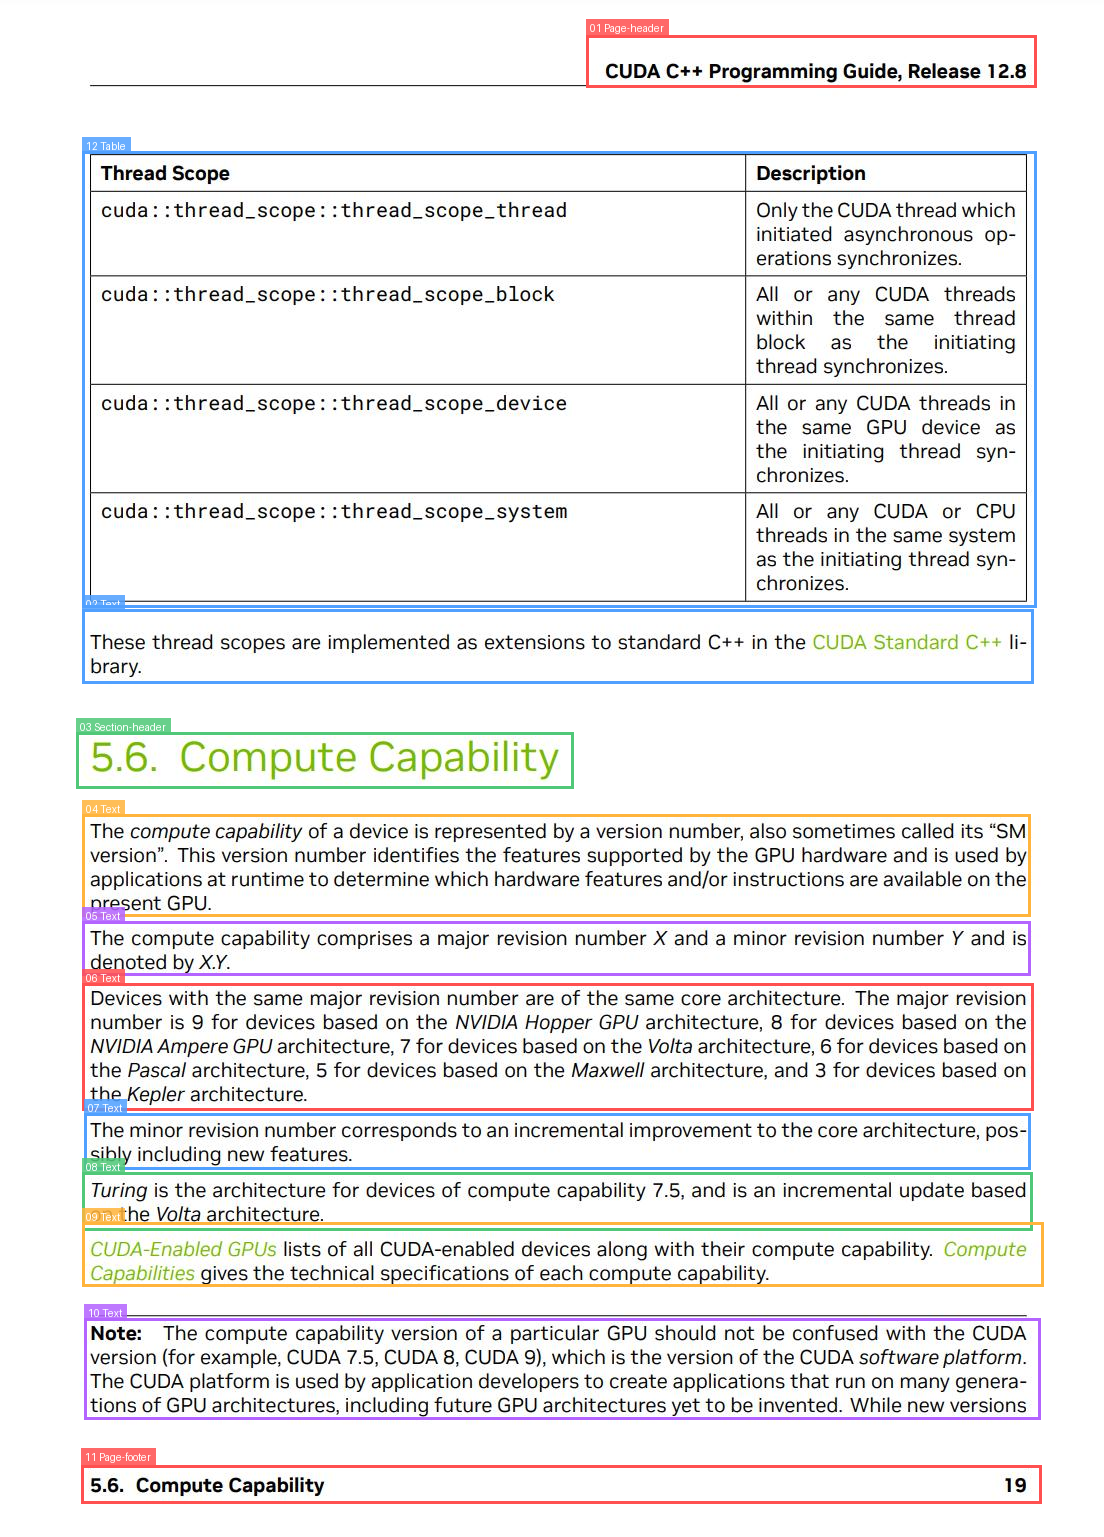

In [9]:
from PIL import ImageDraw, ImageFont

try:
    from IPython.display import display
except ImportError:
    display = lambda image: image


def _walk_bbox_items(value):
    if isinstance(value, dict):
        if "bbox" in value:
            yield value
        for child in value.values():
            yield from _walk_bbox_items(child)
    elif isinstance(value, list):
        for child in value:
            yield from _walk_bbox_items(child)


def _get_reading_order(item, fallback):
    for key in ("reading_order", "readingOrder", "order", "index"):
        value = item.get(key)
        if value is not None:
            try:
                return int(value)
            except (TypeError, ValueError):
                return fallback
    return fallback


def extract_bbox_items(parse_result):
    message = parse_result["choices"][0]["message"]
    tool_calls = message.get("tool_calls") or []
    if not tool_calls:
        raise ValueError("No tool calls found. Use task_id=0 for markdown_bbox output.")

    items = []
    for tool_call in tool_calls:
        arguments = tool_call["function"]["arguments"]
        parsed_arguments = json.loads(arguments)
        items.extend(_walk_bbox_items(parsed_arguments))

    ordered_items = []
    for idx, item in enumerate(items):
        item_with_order = dict(item)
        item_with_order["reading_order"] = _get_reading_order(item_with_order, idx + 1)
        ordered_items.append(item_with_order)

    return ordered_items


def _to_pixel_bbox(bbox, width, height):
    x0 = bbox["xmin"] * width if bbox["xmin"] <= 1 else bbox["xmin"]
    y0 = bbox["ymin"] * height if bbox["ymin"] <= 1 else bbox["ymin"]
    x1 = bbox["xmax"] * width if bbox["xmax"] <= 1 else bbox["xmax"]
    y1 = bbox["ymax"] * height if bbox["ymax"] <= 1 else bbox["ymax"]

    x0, x1 = sorted((max(0, int(round(x0))), min(width, int(round(x1)))))
    y0, y1 = sorted((max(0, int(round(y0))), min(height, int(round(y1)))))
    return x0, y0, x1, y1


def _format_reading_order(reading_order):
    try:
        return f"{int(reading_order):02d}"
    except (TypeError, ValueError):
        return str(reading_order)


def draw_bbox_overlay(image, bbox_items):
    annotated = image.convert("RGB").copy()
    draw = ImageDraw.Draw(annotated, "RGBA")
    width, height = annotated.size
    font = ImageFont.load_default()

    colors = [
        (255, 80, 80),
        (80, 160, 255),
        (80, 200, 120),
        (255, 180, 60),
        (180, 100, 255),
    ]

    for idx, item in enumerate(bbox_items):
        bbox = item["bbox"]
        box_type = item.get("type") or item.get("label") or f"box-{idx + 1}"
        reading_order = item.get("reading_order", idx + 1)
        color = colors[idx % len(colors)]
        x0, y0, x1, y1 = _to_pixel_bbox(bbox, width, height)

        draw.rectangle([x0, y0, x1, y1], outline=(*color, 255), width=3)

        label = f"{_format_reading_order(reading_order)} {box_type}"
        label_bbox = draw.textbbox((x0, y0), label, font=font)
        label_w = label_bbox[2] - label_bbox[0]
        label_h = label_bbox[3] - label_bbox[1]
        label_y0 = max(0, y0 - label_h - 6)

        draw.rectangle(
            [x0, label_y0, x0 + label_w + 8, label_y0 + label_h + 6],
            fill=(*color, 220),
        )
        draw.text((x0 + 4, label_y0 + 3), label, fill=(255, 255, 255, 255), font=font)

    return annotated


bbox_items = extract_bbox_items(parse_result)
print(f"Found {len(bbox_items)} bounding boxes")

annotated_image = draw_bbox_overlay(imag_test_2, bbox_items)
display(annotated_image)


In [10]:
import json


def walk_items(value):
    if isinstance(value, dict):
        if "text" in value:
            yield value
        for child in value.values():
            yield from walk_items(child)
    elif isinstance(value, list):
        for child in value:
            yield from walk_items(child)


def extract_tex_blocks(parse_result):
    tex_blocks = []

    message = parse_result["choices"][0]["message"]
    tool_calls = message.get("tool_calls") or []

    for tool_call in tool_calls:
        arguments = tool_call["function"]["arguments"]

        # arguments is itself a JSON-encoded string
        parsed_arguments = json.loads(arguments)

        for item in walk_items(parsed_arguments):
            text = item.get("text", "")

            if "\\begin{" in text and "\\end{" in text:
                tex_blocks.append(text)

    return tex_blocks


tex_blocks = extract_tex_blocks(parse_result)

for i, tex in enumerate(tex_blocks, start=1):
    print(f"\n--- TeX block {i} ---")
    print(tex)


--- TeX block 1 ---
\begin{tabular}{cc}
Thread Scope & Description \\ cuda::thread_scope::thread_scope_thread & Only the CUDA thread which initiated asynchronous operations synchronizes. \\ cuda::thread_scope::thread_scope_block & All or any CUDA threads within the same thread block as the initiating thread synchronizes. \\ cuda::thread_scope::thread_scope_device & All or any CUDA threads in the same GPU device as the initiating thread synchronizes. \\ cuda::thread_scope::thread_scope_system & All or any CUDA or CPU threads in the same system as the initiating thread synchronizes. \\ \end{tabular}


In [11]:
import re

tex = r"""\begin{tabular}{cc}
**Thread Scope** & **Description** \\ cuda:: thread_scope::thread_scope_thread & Only the CUDA thread which initiated asynchronous operations synchronizes. \\ cuda:: thread_scope::thread_scope_block & All or any CUDA threads within the same thread block as the initiating thread synchronizes. \\ cuda:: thread_scope::thread_scope_device & All or any CUDA threads in the same GPU device as the initiating thread synchronizes. \\ cuda:: thread_scope::thread_scope_system & All or any CUDA or CPU threads in the same system as the initiating thread synchronizes. \\ \end{tabular}"""

def tex_tabular_to_markdown(tex):
    tex = re.sub(r"\\begin\{tabular\}\{.*?\}", "", tex)
    tex = re.sub(r"\\end\{tabular\}", "", tex)

    rows = [row.strip() for row in tex.split(r"\\") if row.strip()]

    md_rows = []
    for row in rows:
        cols = [col.strip() for col in row.split("&")]
        if len(cols) == 2:
            md_rows.append(cols)

    header = md_rows[0]
    body = md_rows[1:]

    md = f"| {header[0]} | {header[1]} |\n"
    md += "|---|---|\n"

    for left, right in body:
        left = left.replace("cuda:: ", "cuda::")
        md += f"| `{left}` | {right} |\n"

    return md

md = tex_tabular_to_markdown(tex)
display(Markdown(md))

| **Thread Scope** | **Description** |
|---|---|
| `cuda::thread_scope::thread_scope_thread` | Only the CUDA thread which initiated asynchronous operations synchronizes. |
| `cuda::thread_scope::thread_scope_block` | All or any CUDA threads within the same thread block as the initiating thread synchronizes. |
| `cuda::thread_scope::thread_scope_device` | All or any CUDA threads in the same GPU device as the initiating thread synchronizes. |
| `cuda::thread_scope::thread_scope_system` | All or any CUDA or CPU threads in the same system as the initiating thread synchronizes. |


## Suggested experiments

* Try extracting Latex equations from screenshots of https://arxiv.org/abs/1802.01528 and compare them with the TeX source https://arxiv.org/src/1802.01528

* Take the output of Nemotron Parse and use it as input for Nemotron 3 Nano Omni.